# KMeans 第一课：聚类与基本思想


## 1. 从“有答案”走向“没有答案”

分类算法的训练数据通常写成：

```text
X -> 样本特征
y -> 样本类别答案
```

模型用 `X` 和 `y` 学习怎样预测类别，这叫有监督学习。

聚类面对的数据不同：

```text
只有 X，没有 y
```

模型没有标准答案可以模仿，只能根据样本本身的结构，把彼此相似的样本聚到一起。这叫无监督学习。

> 聚类不是预测已经规定好的类别，而是在数据中探索可能存在的分组。


## 2. 什么是聚类？

聚类希望做到：

```text
同一组内部 -> 样本尽量相似、距离尽量近
不同组之间 -> 样本差异较大、距离尽量远
```

每一组叫作一个簇（`cluster`）。簇编号 `0`、`1`、`2` 只是模型生成的代号，没有大小关系，也没有固定语义。重新训练后，编号可能互换。


## 3. K-means 名字是什么意思？

```text
K     -> 事先希望分成多少个簇
means -> 每个簇用样本均值作为中心
```

这个中心叫作质心（`centroid`）。

假设一个簇有三个二维样本：

$$
(1, 2),\quad (2, 4),\quad (3, 3)
$$

质心是每一列分别求平均：

$$
\mu
=
\left(\frac{1+2+3}{3},\frac{2+4+3}{3}\right)
=(2, 3)
$$

质心不一定是某个真实样本，它是这一簇样本的平均位置。


## 4. K-means 的核心循环

```text
1. 选择 K 个初始质心
2. 分配：每个样本归到最近的质心
3. 更新：对每个簇重新求均值，得到新质心
4. 重复分配和更新，直到质心基本不再变化
```

可以把它想成不断移动的集合点：

```text
先放置 K 个集合点
-> 每个人走向离自己最近的集合点
-> 集合点移动到本组所有人的平均位置
-> 大家再次选择最近的集合点
-> 反复进行，直到分组稳定
```


## 5. 分配步骤：寻找最近质心

设第 $i$ 个样本是 $x_i$，第 $k$ 个质心是 $\mu_k$：

$$
c_i=\underset{k}{\arg\min}\lVert x_i-\mu_k\rVert_2^2
$$

- $c_i$：第 $i$ 个样本被分到的簇编号；
- $\lVert x_i-\mu_k\rVert_2$：样本和质心的欧氏距离；
- `argmin`：找出“哪个 $k$ 让距离最小”。

平方不会改变谁近谁远，并且方便构造后面的目标函数。


## 6. 更新步骤：重新计算质心

分配完成后，对第 $k$ 个簇中的所有样本求平均：

$$
\mu_k=\frac{1}{|C_k|}\sum_{x_i\in C_k}x_i
$$

其中 $C_k$ 是第 $k$ 个簇的样本集合，$|C_k|$ 是其中的样本数量。

人话版：先决定每个人属于哪一组，再把集合点移动到这一组人的平均位置。


## 7. K-means 在优化什么？

目标函数是簇内平方和：

$$
J=\sum_{k=1}^{K}\sum_{x_i\in C_k}\lVert x_i-\mu_k\rVert_2^2
$$

它把每个样本到所属质心的平方距离全部加起来，衡量当前聚类有多“松散”。这个值也叫 `SSE`；sklearn 训练后可通过 `inertia_` 查看：

```python
print(model.inertia_)
```

值越小，样本整体越靠近各自质心。但不能只追求它越小越好，因为增大 `K` 通常就能继续降低它。


## 8. 第一次使用 sklearn

生成三团二维样本：

```python
from sklearn.datasets import make_blobs

X, _ = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=0.75,
    random_state=22,
)
```

`make_blobs` 会返回人工标签，但 K-means 训练时不应该看到它，所以用 `_` 忽略。

创建并训练模型：

```python
from sklearn.cluster import KMeans

model = KMeans(n_clusters=3, random_state=22, n_init=10)
labels = model.fit_predict(X)
```

重要参数和结果：

```text
n_clusters=3     -> K=3，希望分成三个簇
random_state=22  -> 固定随机过程，方便复现
n_init=10        -> 尝试 10 组初始质心，保留较好结果
labels           -> 每个样本的簇编号
cluster_centers_ -> 最终质心
inertia_         -> 簇内平方和
```

```python
print(labels[:10])
print(model.cluster_centers_)
print(model.inertia_)
```

完整可运行代码见 [kmeans_basic.py](kmeans_basic.py)。


## 9. `fit_predict` 做了什么？

```python
labels = model.fit_predict(X)
```

可以先理解为：

```python
model.fit(X)
labels = model.predict(X)
```

它和分类模型最明显的区别是：

```text
分类模型 fit(X, y) -> 需要特征和答案
K-means  fit(X)    -> 只需要特征
```


## 10. 与 KNN 的区别

| 对比项 | KNN | K-means |
|---|---|---|
| 学习类型 | 有监督学习 | 无监督学习 |
| 训练数据 | `X` 和 `y` | 只有 `X` |
| `K` 的含义 | 最近的 K 个邻居 | 数据分成 K 个簇 |
| 距离对象 | 新样本与训练样本 | 样本与质心 |
| 输出 | 已知类别或连续值 | 模型发现的簇编号 |


## 11. 为什么标准化仍然重要？

如果特征是年龄和年收入，收入的数值范围远大于年龄，直接计算欧氏距离时结果几乎会被收入控制。

因此 K-means 和 KNN 一样，真实案例中通常要检查特征尺度：

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
```

本课的二维模拟数据坐标尺度接近，可以先直接聚类。


## 12. 现在先记住的局限

- 必须提前给出 `K`；
- 初始质心可能影响结果；
- 对异常值比较敏感；
- 更擅长发现近似圆形、大小相近的簇；
- 特征尺度会直接影响距离；
- 簇编号没有业务含义，需要事后解释。


## 13. 本课小结

1. 聚类只有 `X`，没有现成 `y`，属于无监督学习；
2. `K` 表示希望得到的簇数量；
3. 质心是簇内样本的平均位置；
4. K-means 不断重复“分配样本”和“更新质心”；
5. 它要减小所有样本到所属质心的平方距离之和。

```text
初始化质心
-> 分配到最近质心
-> 用簇内均值更新质心
-> 重复直到稳定
```

下一课将拆开目标函数，并手算一轮 K-means。


## 14. 课后小练习

1. 用一句话说明 KNN 的 `K` 和 K-means 的 `K` 有什么不同。
2. 如果有 100 个样本、4 个特征，`X.shape` 是多少？K-means 需要 `y` 吗？
3. 一个簇包含 `(1, 1)`、`(2, 3)`、`(6, 2)`，请手算新质心。
4. 把示例的 `n_clusters` 改成 `2` 和 `4`，观察图像与 `inertia_` 的变化。
5. 为什么 `K` 等于样本数量时，`inertia_` 可以降到 0，但聚类通常没有意义？


## 15. 完整代码示例

下面把前面讲过的所有步骤串成一个完整示例。

代码做的事：

1. 用 `make_blobs` 生成 300 个样本、3 个簇的人工数据
2. 创建 `KMeans(n_clusters=3)` 模型
3. 调用 `fit_predict(X)` 一步完成训练和分配
4. 打印 `cluster_centers_` 查看质心坐标
5. 打印 `inertia_` 查看当前聚类的好坏
6. 画出聚类结果和质心位置

你可以试着把 `n_clusters` 改成 2 或 4，对比 `n_clusters` 和 `inertia_` 的变化。


X shape: (300, 2)
First 10 cluster labels: [2 0 2 1 1 2 2 0 2 2]
Centroids:
 [[-6.5869185  -3.34014844]
 [-1.57142529  7.28240381]
 [-5.77334543 -0.28747543]]
Inertia: 360.65


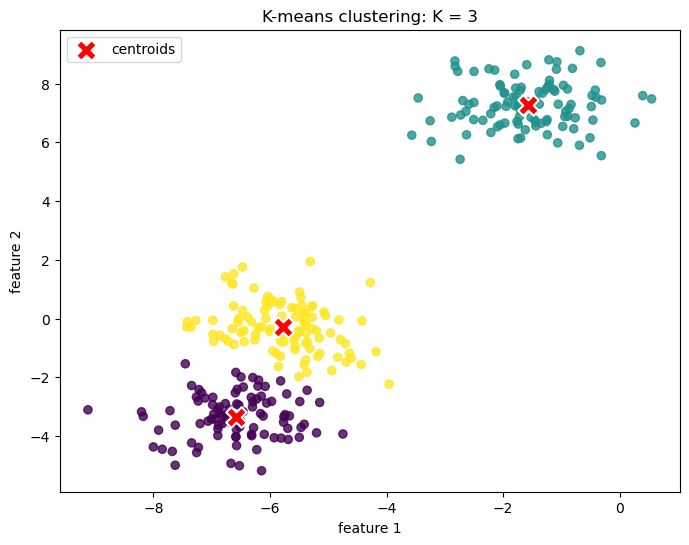

In [1]:
import os

# Avoid a known Windows + MKL warning for small K-means datasets.
os.environ["OMP_NUM_THREADS"] = "1"

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# The generated labels are ignored; K-means only sees X.
X, _ = make_blobs(
    n_samples=300, centers=3, cluster_std=0.75, random_state=22
)

model = KMeans(n_clusters=3, random_state=22, n_init=10)
labels = model.fit_predict(X)
centers = model.cluster_centers_

print("X shape:", X.shape)
print("First 10 cluster labels:", labels[:10])
print("Centroids:\n", centers)
print("Inertia:", round(model.inertia_, 2))

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis", s=35, alpha=0.8)
plt.scatter(
    centers[:, 0], centers[:, 1], c="red", marker="X", s=220,
    edgecolors="white", linewidths=1.5, label="centroids"
)
plt.title("K-means clustering: K = 3")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.legend()
plt.show()
